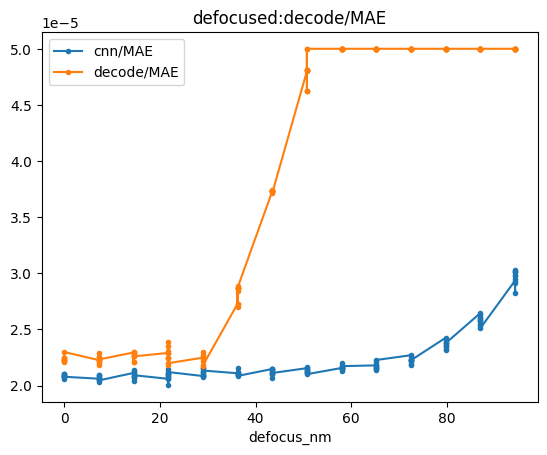

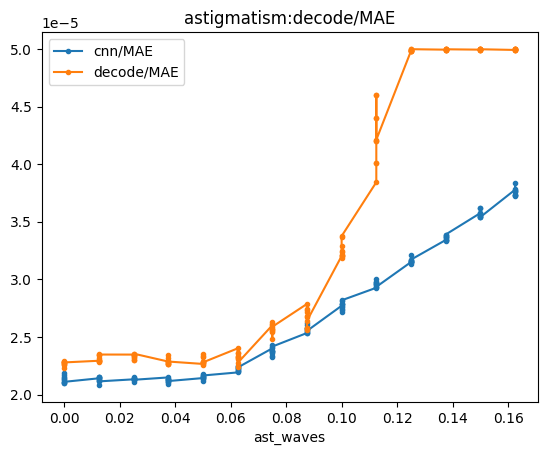

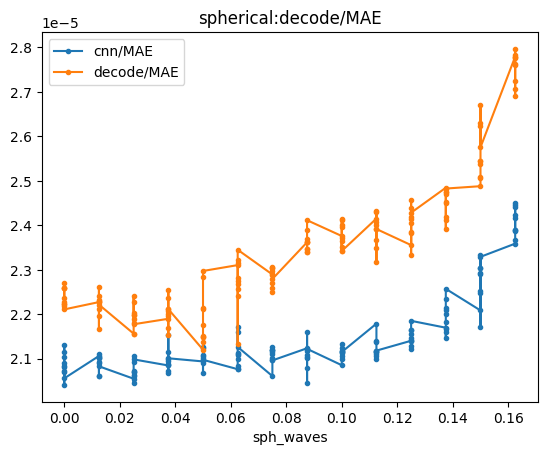

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from scipy.stats import entropy
import h5py

# Image similarity metrics
def MAE(imA, imB, blur=2):
    imAn = norm(ndi.gaussian_filter(imA, blur))
    imBn = norm(ndi.gaussian_filter(imB, blur))
    return np.mean(np.abs(imAn.ravel() - imBn.ravel()))

def KLD(im_test, im_ref, blur=2, prevent_infty=True):
    imAn = norm(ndi.gaussian_filter(im_test, blur).ravel()) #+ 1e-9 #tested distribution
    if prevent_infty:
        imAn += 1e-10 #this is the value that adds the CNN to dark pixels, this is the typical background value for CNN output
    imBn = norm(ndi.gaussian_filter(im_ref, blur).ravel()) #+ 1e-9 #reference distribution    
    #order here is important, first comes reference
    return entropy(imBn/np.sum(imBn), imAn/np.sum(imAn), base=2)

def norm(a):
    asu = a - np.min(a)
    norm = np.sum(asu)    
    if norm == 0:
        #for zero-array, skip normalization (to avoid zero-division)
        return np.zeros_like(a)
    return asu/norm

def norm_stack(stack):
    return np.array([norm(img)+1e-10 for img in stack])


BLUR = 2
#metrics of interest
metrics = {
    'MAE' : lambda x, y : MAE(x, y, BLUR),
    # 'KLD' : lambda x, y : KLD(x, y, BLUR)
}


SUFFIXES = ['defocused', 'astigmatism', 'spherical']
param_name = ['defocus_nm', 'ast_waves',"sph_waves"]

for suf, pname in zip(SUFFIXES, param_name):
    fn_in_h5 = f'data/input_for_cnn_star_w_psfs_{suf}.h5'
    fn_decode_render = f'data/decode_render_star_{suf}.h5'
    fn_cnn = f'data/cnn_output_star_{suf}.h5'    
    with h5py.File(fn_in_h5, 'r') as h5f:
        gt_image = np.array(h5f['reference'])
        abber_size = np.array(h5f[pname])
        mc_size = h5f.attrs['gen_params_mc_samples']          
    with h5py.File(fn_cnn, 'r') as h5f:
        cnn_stack = norm_stack(np.array(h5f['outputs']))
        # gt_image = np.array(h5f['reference'])        
    with h5py.File(fn_decode_render, 'r') as h5f:
        decode_stack = norm_stack(np.array(h5f['rendered_frames']))    
    reconst_methods = {
        'cnn' : cnn_stack,
        'decode' : decode_stack,
    }
    metrics_results = dict()
    xax = np.kron(abber_size, np.ones(10)).ravel()
    for rkey in reconst_methods:
        tested_dataset = reconst_methods[rkey]
        datalines = []
        for mkey in metrics:
            compount_key = f'{rkey}/{mkey}'
            foo = metrics[mkey]
            subresults = np.array([foo(imtest, gt_image) for imtest in tested_dataset])
            metrics_results[compount_key] = subresults.ravel()
            plt.plot(xax[0:140], metrics_results[compount_key].ravel()[0:140], ".-", label=compount_key)
    plt.legend()
    plt.title(suf+':'+compount_key)
    plt.xlabel(pname)
    plt.show()
        


# #Select only MEF results with at least one emitter.
# #Zero-emitter results are considered outright wrong.
# thstmask = make_mask(thstdata)
# thstdata = norm_stack(thstdata)

# #Further infos about references.
# info = np.load('star_truth_info.npz')
# print(info.files)
# snrs = info['snrs']
# xys = info['xys']

In [ ]:
# reconst_methods = {
#     'cnn' : cnndata,
#     'decode' : rldata,
#     'thst' : thstdata
#     }

# metrics_results = dict()
# for rkey in reconst_methods:
#     tested_dataset = reconst_methods[rkey]
#     datalines = []
#     for mkey in metrics:
#         compount_key = f'{rkey}/{mkey}'
#         foo = metrics[mkey]
#         subresults = np.array([foo(imtest, imref) for imtest, imref in zip(tested_dataset, refdata)])
#         metrics_results[compount_key] = subresults.reshape((-1,10))

# #Save the numbers to h5 file for possible stand-alone production of the plots
# #without rerunning the whole notebook.
# with h5py.File('star_saved_metrics.h5', 'w') as h5f:
#     for ckey in metrics_results.keys():
#         h5f.create_dataset(ckey, data = metrics_results[ckey])